In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler , LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn import datasets
import warnings
warnings.filterwarnings('ignore')

In [2]:
data = pd.read_csv('/kaggle/input/ndsc-regression-cholesterol-prediction/train.csv')

In [3]:
data

,Jenis Kelamin,Usia,Tekanan darah (S),Tekanan darah (D),Tinggi badan (cm),Berat badan (kg),IMT (kg/m2),Lingkar perut (cm),Glukosa Puasa (mg/dL),Trigliserida (mg/dL),Fat,Visceral Fat,Masa Kerja,Tempat lahir,Cholesterol Total (mg/dL)
0,M,35.0,120.0,78.0,164.0,47.60,18.00,65.0,84.0,143.0,26.4,6.0,15.00,Bogor,179.0
1,M,29.0,100.0,66.0,162.9,68.50,25.81,87.0,84.0,90.0,26.4,6.0,6.33,Tasikmalaya,198.0
2,M,38.0,110.0,78.0,155.0,68.25,27.70,84.0,84.0,46.0,26.4,6.0,24.00,Banjarnegara,153.0
3,M,27.0,110.0,65.0,160.0,53.65,21.30,65.0,84.0,99.0,26.4,6.0,4.00,Bogor,187.0
4,M,36.0,100.0,70.0,170.0,77.35,26.76,93.0,81.0,88.0,25.2,12.0,16.00,Nias,178.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1066,F,33.0,120.0,80.0,161.3,51.95,19.96,78.0,84.0,65.0,26.4,6.0,8.00,Bogor,171.0
1067,M,34.0,110.0,70.0,165.0,71.90,26.40,89.0,81.0,214.0,26.4,6.0,13.04,Bogor,221.0
1068,F,39.0,120.0,70.0,157.5,64.00,25.79,85.0,78.0,91.0,36.2,7.5,17.00,Jakarta,183.0
1069,M,30.0,90.0,60.0,171.0,55.50,18.98,77.0,84.0,166.0,26.4,6.0,6.00,Jakarta,182.0


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1071 entries, 0 to 1070
Data columns (total 15 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Jenis Kelamin              1071 non-null   object 
 1   Usia                       1071 non-null   float64
 2   Tekanan darah  (S)         1071 non-null   float64
 3   Tekanan darah  (D)         1071 non-null   float64
 4   Tinggi badan (cm)          1071 non-null   float64
 5   Berat badan (kg)           1071 non-null   float64
 6   IMT (kg/m2)                1071 non-null   float64
 7   Lingkar perut (cm)         1071 non-null   float64
 8   Glukosa Puasa (mg/dL)      1071 non-null   float64
 9   Trigliserida (mg/dL)       1071 non-null   float64
 10  Fat                        1071 non-null   float64
 11  Visceral Fat               1071 non-null   float64
 12  Masa Kerja                 1071 non-null   float64
 13  Tempat lahir               1071 non-null   objec

In [5]:
data.isnull().sum()

Jenis Kelamin                0
Usia                         0
Tekanan darah  (S)           0
Tekanan darah  (D)           0
Tinggi badan (cm)            0
Berat badan (kg)             0
IMT (kg/m2)                  0
Lingkar perut (cm)           0
Glukosa Puasa (mg/dL)        0
Trigliserida (mg/dL)         0
Fat                          0
Visceral Fat                 0
Masa Kerja                   0
Tempat lahir                 0
Cholesterol Total (mg/dL)    0
dtype: int64

In [6]:
data.duplicated().sum()

0

In [7]:
data.nunique()

Jenis Kelamin                  2
Usia                          21
Tekanan darah  (S)            32
Tekanan darah  (D)            32
Tinggi badan (cm)            205
Berat badan (kg)             587
IMT (kg/m2)                  629
Lingkar perut (cm)            84
Glukosa Puasa (mg/dL)         44
Trigliserida (mg/dL)         176
Fat                          161
Visceral Fat                  39
Masa Kerja                   211
Tempat lahir                 152
Cholesterol Total (mg/dL)    136
dtype: int64

In [8]:
data.describe()

,Usia,Tekanan darah (S),Tekanan darah (D),Tinggi badan (cm),Berat badan (kg),IMT (kg/m2),Lingkar perut (cm),Glukosa Puasa (mg/dL),Trigliserida (mg/dL),Fat,Visceral Fat,Masa Kerja,Cholesterol Total (mg/dL)
count,1071.000000,1071.000000,1071.000000,1071.000000,1071.000000,1071.000000,1071.000000,1071.000000,1071.000000,1071.000000,1071.000000,1071.000000,1071.000000
mean,28.563025,113.071895,73.867414,164.954435,64.660551,23.709869,80.467320,84.521942,107.000000,26.214099,6.190289,6.332260,188.139122
std,4.731432,10.132554,7.701267,7.438620,12.779196,4.026620,10.585122,10.973683,42.343411,3.733596,2.312534,4.543245,21.597643
min,19.000000,80.000000,58.000000,138.500000,38.500000,14.850000,54.000000,65.000000,34.000000,5.800000,0.500000,0.000000,103.000000
25%,25.000000,110.000000,70.000000,160.000000,55.350000,20.860000,73.000000,84.000000,99.000000,26.400000,6.000000,4.000000,187.000000
50%,28.000000,110.000000,72.000000,165.000000,62.650000,23.200000,80.000000,84.000000,99.000000,26.400000,6.000000,6.000000,187.000000
75%,31.000000,120.000000,80.000000,170.350000,71.700000,26.050000,87.000000,84.000000,99.000000,26.400000,6.000000,8.000000,187.000000
max,39.000000,170.000000,100.000000,187.500000,139.750000,44.100000,128.000000,321.000000,634.000000,40.900000,22.000000,31.000000,308.000000


In [9]:
data['Jenis Kelamin'].value_counts().reset_index()

,Jenis Kelamin,count
0,M,808
1,F,263


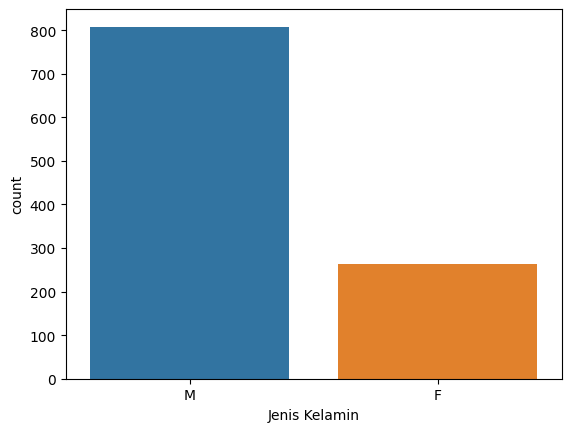

In [10]:
sns.countplot(x = 'Jenis Kelamin', data=data)
plt.show()

In [11]:
data['Tempat lahir'].value_counts().nlargest(70).reset_index()

,Tempat lahir,count
0,Bogor,277
1,Jakarta,217
2,Bandung,115
3,Bekasi,48
4,Temanggung,25
...,...,...
65,Nganjuk,2
66,Serang,2
67,Kendal,2
68,Kab. Semarang,2


In [12]:
values = data['Tempat lahir'].value_counts().nlargest(70)
index = data['Tempat lahir'].value_counts().nlargest(70).index

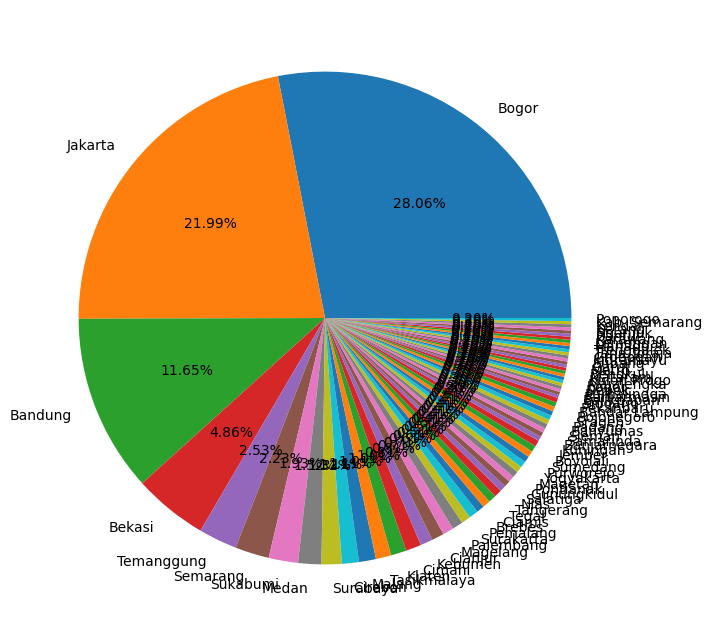

In [13]:
plt.figure(figsize = (10,8))
plt.pie(values,labels = index,autopct='%0.2f%%')
plt.show()

In [14]:
le = LabelEncoder()
data['Jenis Kelamin'] = le.fit_transform(data['Jenis Kelamin'])
data['Tempat lahir'] =  le.fit_transform(data['Tempat lahir'])

In [15]:
correlation = data.corr().round(2)

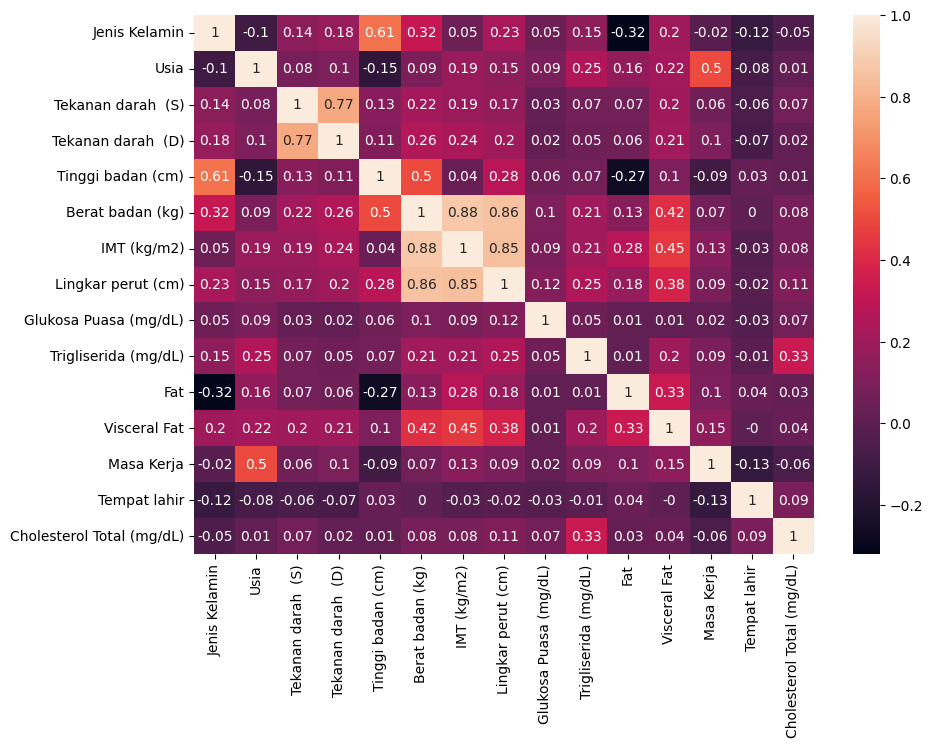

In [16]:
plt.figure(figsize = (10,7))
sns.heatmap(correlation,annot = True)
plt.show()

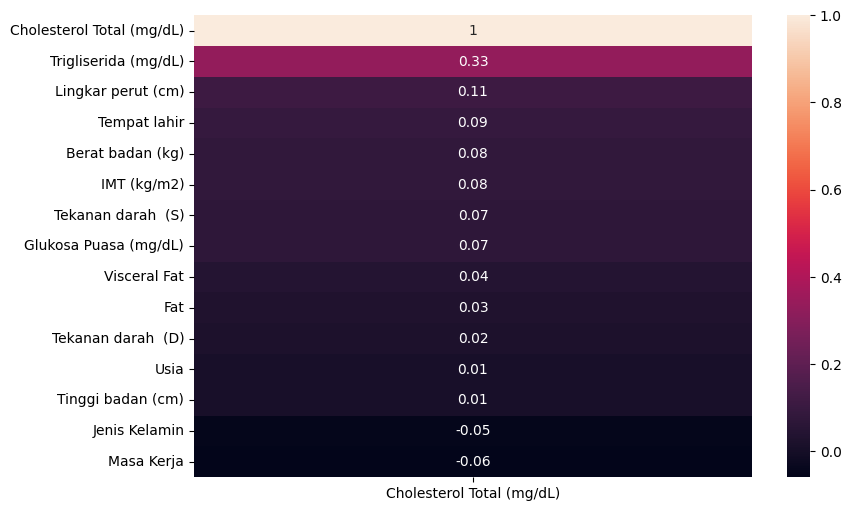

In [17]:
plt.figure(figsize = (9,6))
sns.heatmap(correlation[['Cholesterol Total (mg/dL)']].sort_values(by = ['Cholesterol Total (mg/dL)'],ascending = False),annot = True)
plt.show()


In [18]:
x = data.drop('Cholesterol Total (mg/dL)',axis=1)
y = data['Cholesterol Total (mg/dL)']

In [19]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.3,random_state=42)

In [20]:
scaler = MinMaxScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [21]:
model_1 = LinearRegression()
model_1.fit(x_train , y_train) 

LinearRegression()

In [22]:
y_train_pred = model_1.predict(x_train)
y_test_pred = model_1.predict(x_test)

mse_train =  np.sqrt(mean_squared_error(y_train, y_train_pred))
mse_test =  np.sqrt(mean_squared_error(y_test, y_test_pred))

r2_train = r2_score(y_train, y_train_pred)
r2_test = r2_score(y_test, y_test_pred)

print("Mean Squared Error (Train):", mse_train)
print("Mean Squared Error (Test):", mse_test)
print("R-squared (Train):", r2_train)
print("R-squared (Test):", r2_test)

Mean Squared Error (Train): 19.56427502491748
Mean Squared Error (Test): 21.065853975791473
R-squared (Train): 0.20012928622178472
R-squared (Test): -0.015841736025627995


In [23]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

In [24]:
poly = PolynomialFeatures(degree=2, include_bias=False)
x_poly = poly.fit_transform(x)

In [25]:
x_train_poly, x_test_poly, y_train_poly, y_test_poly = train_test_split(x_poly, y, test_size=0.3, random_state=42)

In [26]:
scaler = MinMaxScaler()
x_train_poly = scaler.fit_transform(x_train_poly)
x_test_poly = scaler.transform(x_test_poly)

In [27]:
# Create a polynomial regression model (Linear Regression with polynomial features)
model_poly = LinearRegression()
model_poly.fit(x_train_poly, y_train_poly)

LinearRegression()

In [28]:
# Make predictions
y_train_pred_poly = model_poly.predict(x_train_poly)
y_test_pred_poly = model_poly.predict(x_test_poly)

# Evaluate the model
mse_train_poly =  np.sqrt(mean_squared_error(y_train_poly, y_train_pred_poly))
mse_test_poly = np.sqrt( mean_squared_error(y_test_poly, y_test_pred_poly))

r2_train_poly = r2_score(y_train_poly, y_train_pred_poly)
r2_test_poly = r2_score(y_test_poly, y_test_pred_poly)

print("Polynomial Regression (Degree 2)")
print("Mean Squared Error (Train):", mse_train_poly)
print("Mean Squared Error (Test):", mse_test_poly)
print("R-squared (Train):", r2_train_poly)
print("R-squared (Test):", r2_test_poly)

Polynomial Regression (Degree 2)
Mean Squared Error (Train): 16.833897713221532
Mean Squared Error (Test): 28.865439622597954
R-squared (Train): 0.40780921471571085
R-squared (Test): -0.9073230862952568


In [29]:
from sklearn.linear_model import Lasso

In [30]:
# You can adjust the 'alpha' parameter (regularization strength)
lasso_model = Lasso(alpha=0.1) # Example alpha value

# Fit the Lasso model on the polynomial features (using the scaled training data)
lasso_model.fit(x_train_poly, y_train_poly)

Lasso(alpha=0.1)

In [31]:
# Make predictions using the Lasso model
y_train_pred_lasso = lasso_model.predict(x_train_poly)
y_test_pred_lasso = lasso_model.predict(x_test_poly)

# Evaluate the Lasso model
mse_train_lasso =  np.sqrt(mean_squared_error(y_train_poly, y_train_pred_lasso))
mse_test_lasso =  np.sqrt(mean_squared_error(y_test_poly, y_test_pred_lasso))

r2_train_lasso = r2_score(y_train_poly, y_train_pred_lasso)
r2_test_lasso = r2_score(y_test_poly, y_test_pred_lasso)

print("\nLasso Regression (Polynomial Features, Alpha=0.1)")
print("Mean Squared Error (Train):", mse_train_lasso)
print("Mean Squared Error (Test):", mse_test_lasso)
print("R-squared (Train):", r2_train_lasso)
print("R-squared (Test):", r2_test_lasso)


Lasso Regression (Polynomial Features, Alpha=0.1)
Mean Squared Error (Train): 19.52777572986936
Mean Squared Error (Test): 21.081654790546764
R-squared (Train): 0.2031109948898795
R-squared (Test): -0.017366207506856135


In [32]:
from sklearn.linear_model import Ridge

In [33]:
# You can adjust the 'alpha' parameter (regularization strength)
ridge_model = Ridge(alpha=1.0) # Example alpha value

# Fit the Ridge model on the polynomial features (using the scaled training data)
ridge_model.fit(x_train_poly, y_train_poly)


Ridge()

In [34]:
# Make predictions using the Ridge model
y_train_pred_ridge = ridge_model.predict(x_train_poly)
y_test_pred_ridge = ridge_model.predict(x_test_poly)

# Evaluate the Ridge model
mse_train_ridge =  np.sqrt(mean_squared_error(y_train_poly, y_train_pred_ridge))
mse_test_ridge =  np.sqrt(mean_squared_error(y_test_poly, y_test_pred_ridge))

r2_train_ridge = r2_score(y_train_poly, y_train_pred_ridge)
r2_test_ridge = r2_score(y_test_poly, y_test_pred_ridge)

print("\nRidge Regression (Polynomial Features, Alpha=1.0)")
print("Root Mean Squared Error (Train):", mse_train_ridge)
print("Mean Squared Error (Test):", mse_test_ridge)
print("R-squared (Train):", r2_train_ridge)
print("R-squared (Test):", r2_test_ridge)


Ridge Regression (Polynomial Features, Alpha=1.0)
Root Mean Squared Error (Train): 18.70476022371206
Mean Squared Error (Test): 21.919145938161932
R-squared (Train): 0.26886669417436815
R-squared (Test): -0.09980368247737537
